In [1]:
import json
from pathlib import Path
import numpy as np
import cv2
import matplotlib.pyplot as plt
from skimage.filters import threshold_otsu, meijering
from skimage.morphology import remove_small_objects, remove_small_holes, disk, binary_dilation, skeletonize
from skimage.exposure import rescale_intensity
from scipy.ndimage import map_coordinates, gaussian_filter1d
from skimage.restoration import inpaint
from scipy.ndimage import gaussian_filter
from itertools import groupby
from operator import itemgetter
from tifffile import imread
from dataclasses import dataclass, asdict
from typing import Optional
from skimage.transform import resize
from skimage.filters import frangi
from skimage.measure import label, regionprops
import networkx as nx
from scipy.spatial import cKDTree
from scipy.interpolate import splprep, splev

In [2]:
IMG_PATH = "../_images/11042025_S2_F(3)_1-350_green_tiff/20251105_043403_green.tif"

PERC_LOW, PERC_HIGH = 1, 99       # percentiles for normalization
MEIJERING_SIGMAS = np.geomspace(1, 7, 5)  # vesselness scales (user used these)
MIN_OBJECT_SIZE = 200            # remove tiny speckles (increase for high-res)
BG_SIGMA = 60                     # gaussian sigma for background estimation (>> vessel width)
DILATE_RADIUS = 1                 # small dilation to ensure vessels are masked
VERT_THRESHOLD_FACTOR = 1.1       # vertical projection threshold factor (mean + factor*std)
HORIZ_PERCENTILE = 50             # horizontal detection fallback percentile
HORIZ_MARGIN_PIX = 2000           # fallback horizontal crop half-width if needed
VERT_MARGIN_FRAC = 0.12           # fraction of band height to expand vertically

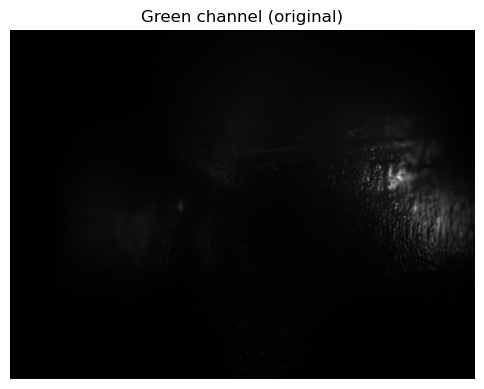

In [3]:
img_path = Path(IMG_PATH)
image = imread(IMG_PATH)

plt.figure(figsize=(6,6))
plt.title("Green channel (original)")
plt.imshow(image, cmap='gray')
plt.axis('off')
plt.show()

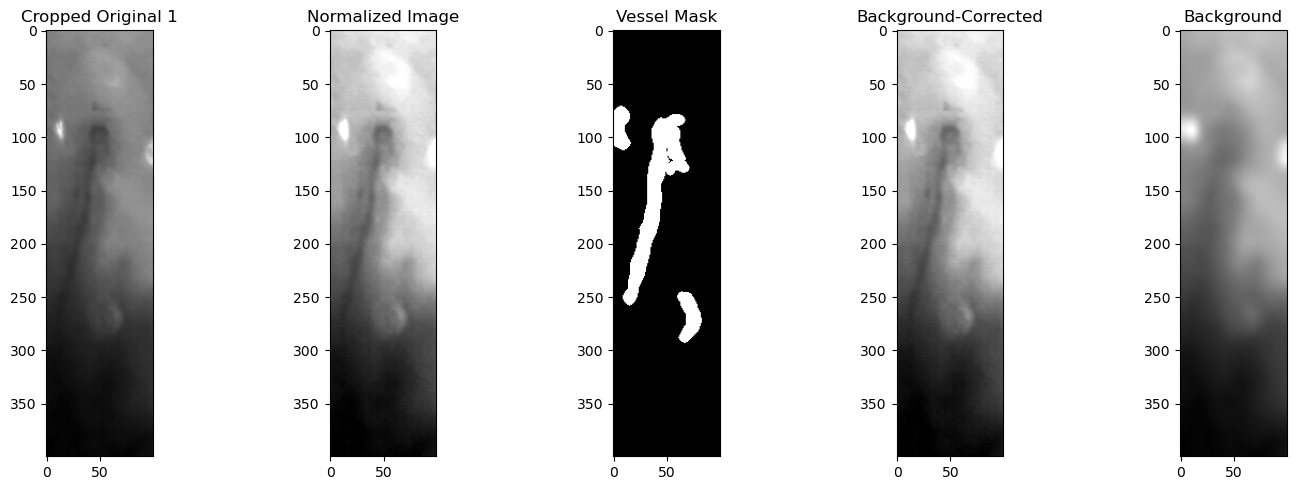

In [4]:
cropped_img_1 = image[1300:1700, 2400:2500] 

p1, p99 = np.percentile(cropped_img_1, (1, 99))
img_n = np.clip((cropped_img_1 - p1) / (p99 - p1 + 1e-8), 0, 1)

sigmas = np.geomspace(2, 3, 2)
vessel_resp = meijering(img_n, sigmas=sigmas, black_ridges=True)
vessel_resp = (vessel_resp - vessel_resp.min()) / (vessel_resp.max() - vessel_resp.min() + 1e-8)

BW = vessel_resp > threshold_otsu(vessel_resp)
BW = remove_small_objects(BW, min_size=200)
BW = remove_small_holes(BW, area_threshold=300)
BW = binary_dilation(BW, disk(4))

mask = BW.astype(bool)
img_inp = inpaint.inpaint_biharmonic(cropped_img_1, mask, channel_axis=None)
bg = gaussian_filter(img_inp, sigma=4)
img_corr = np.clip(img_n - bg + bg.mean(), 0, 1)

fig, axes = plt.subplots(1, 5, figsize=(15,5))
axes[0].imshow(cropped_img_1, cmap='gray')
axes[0].set_title('Cropped Original 1')
axes[0].axis('on')

axes[1].imshow(img_n, cmap='gray')
axes[1].set_title('Normalized Image')
axes[1].axis('on')

axes[2].imshow(BW, cmap='gray')
axes[2].set_title('Vessel Mask')
axes[2].axis('on')

axes[3].imshow(img_corr, cmap='gray')
axes[3].set_title('Background-Corrected')
axes[3].axis('on')

axes[4].imshow(bg, cmap='gray')
axes[4].set_title('Background')
axes[4].axis('on')

plt.tight_layout()
plt.show()


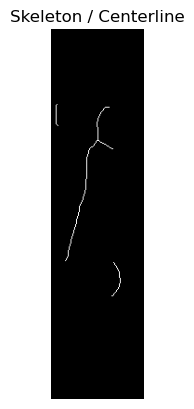

Number of centerline points: 251


In [5]:
BW_smooth = gaussian_filter(BW.astype(float), sigma=2)
skeleton = skeletonize(BW_smooth > 0.5)
centerline_coords_filter = []

plt.imshow(skeleton, cmap='gray')
plt.title("Skeleton / Centerline")
plt.axis('off')
plt.show()

centerline_coords = np.column_stack(np.nonzero(skeleton))
print("Number of centerline points:", len(centerline_coords))


In [6]:
# --- Step 1: Extract skeleton and keep largest connected branch ---
skeleton = skeletonize(BW)
labeled = label(skeleton)
regions = regionprops(labeled)
largest_region = max(regions, key=lambda r: r.area)
skeleton_largest = (labeled == largest_region.label)

coords = np.column_stack(np.nonzero(skeleton_largest))

# --- Step 2: Build skeleton graph and find longest path ---
tree = cKDTree(coords)
edges = []
for i, pt in enumerate(coords):
    neighbors_idx = tree.query_ball_point(pt, 1.5)  # connect neighbors within ~1.5 px
    for n in neighbors_idx:
        if n != i:
            edges.append((i, n))

G = nx.Graph()
G.add_edges_from(edges)
endpoints = [n for n, d in G.degree() if d == 1]

longest_path = []
max_len = 0
for i in range(len(endpoints)):
    for j in range(i+1, len(endpoints)):
        path = nx.shortest_path(G, endpoints[i], endpoints[j])
        if len(path) > max_len:
            max_len = len(path)
            longest_path = path

centerline_ordered = coords[longest_path]

Total arc length: 178.17 pixels. Resampling to 178 points.


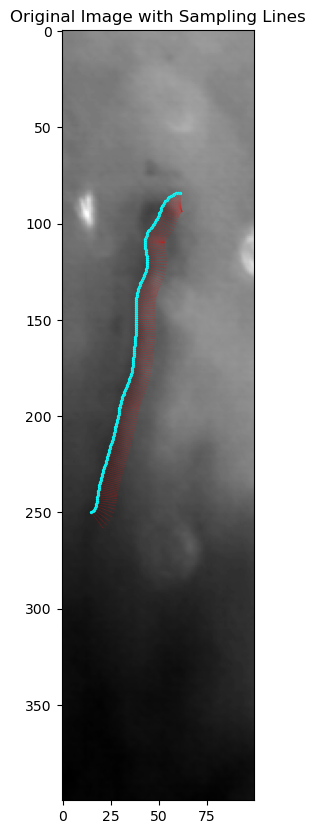

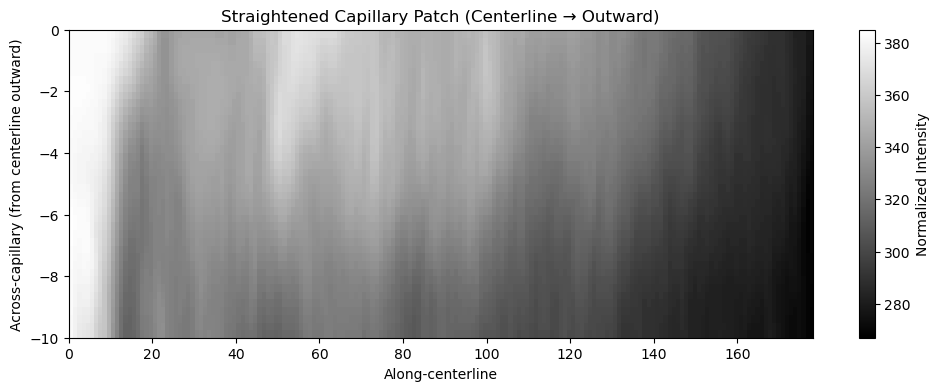

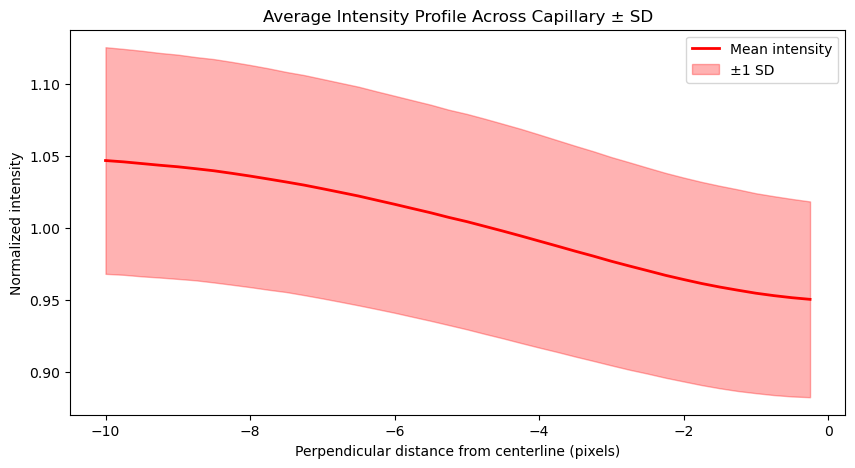

In [7]:
# --- Step 3: Resample centerline smoothly by arc length ---
tck, u = splprep([centerline_ordered[:, 1], centerline_ordered[:, 0]], s=15)
u_fine = np.linspace(0, 1, 5000)
x_fine, y_fine = splev(u_fine, tck)

arc_len = np.cumsum(np.hypot(np.diff(x_fine), np.diff(y_fine)))
arc_len = np.insert(arc_len, 0, 0)
total_arc_length = arc_len[-1]

sampling_step = 1.0  # (in pixels)
num_new_points = int(np.round(total_arc_length / sampling_step))
print(f"Total arc length: {total_arc_length:.2f} pixels. Resampling to {num_new_points} points.")

target_len = np.linspace(0, total_arc_length, num_new_points)
u_new = np.interp(target_len, arc_len, u_fine)
x_smooth, y_smooth = splev(u_new, tck)
centerline_resampled = np.vstack([y_smooth, x_smooth]).T  # (row, col)

# --- Step 4: Compute smooth, consistent normals ---
x_tangent, y_tangent = splev(u_new, tck, der=1)
normals = np.vstack([-y_tangent, x_tangent]).T
lengths = np.sqrt(np.sum(normals**2, axis=1))
normals /= lengths[:, np.newaxis]

for i in range(1, len(normals)):
    if np.dot(normals[i], normals[i-1]) < 0:
        normals[i] *= -1

normals_offset = normals

# --- Step 5: Straighten capillary with high-quality interpolation ---
width = 10
offsets = np.arange(-width, 0, 0.25)  # 4× oversampling

straight_capillary = []

plt.figure(figsize=(10, 10))
plt.imshow(cropped_img_1, cmap='gray')
plt.title("Original Image with Sampling Lines")

for (y, x), (nx, ny) in zip(centerline_resampled, normals_offset):
    y_line = y + ny * offsets
    x_line = x + nx * offsets
    patch = map_coordinates(cropped_img_1, [y_line, x_line], order=3, mode='reflect')
    straight_capillary.append(patch)
    plt.plot(x_line, y_line, color='r', alpha=0.3, linewidth=0.5)

plt.scatter(centerline_resampled[:, 1], centerline_resampled[:, 0],
            color='cyan', s=2)
plt.show()

straight_capillary = np.array(straight_capillary).T  # (across, along)

# --- Step 7: Normalize to background (edges of capillary) ---
bg_val = np.mean(np.concatenate(
    [straight_capillary[:10, :], straight_capillary[-10:, :]], axis=0))
capillary_norm = straight_capillary / (bg_val + 1e-8)

# --- Step 8: Compute mean and std intensity across centerline ---
avg_profile = np.nanmean(capillary_norm, axis=1)
std_profile = np.nanstd(capillary_norm, axis=1)

# --- Step 9: Visualize straightened capillary patch ---
plt.figure(figsize=(12, 4))
plt.imshow(straight_capillary, cmap='gray', aspect='auto',
           extent=[0, straight_capillary.shape[1], -width, 0])
plt.title("Straightened Capillary Patch (Centerline → Outward)")
plt.xlabel("Along-centerline")
plt.ylabel("Across-capillary (from centerline outward)")
plt.colorbar(label='Normalized Intensity')
plt.show()

# --- Step 10: Visualize average intensity profile ---
px = np.arange(-width, 0, 0.25)
plt.figure(figsize=(10, 5))
plt.plot(px, avg_profile, color='red', linewidth=2, label='Mean intensity')
plt.fill_between(px, avg_profile - std_profile, avg_profile + std_profile,
                 color='red', alpha=0.3, label='±1 SD')
plt.xlabel("Perpendicular distance from centerline (pixels)")
plt.ylabel("Normalized intensity")
plt.title("Average Intensity Profile Across Capillary ± SD")
plt.legend()
plt.show()

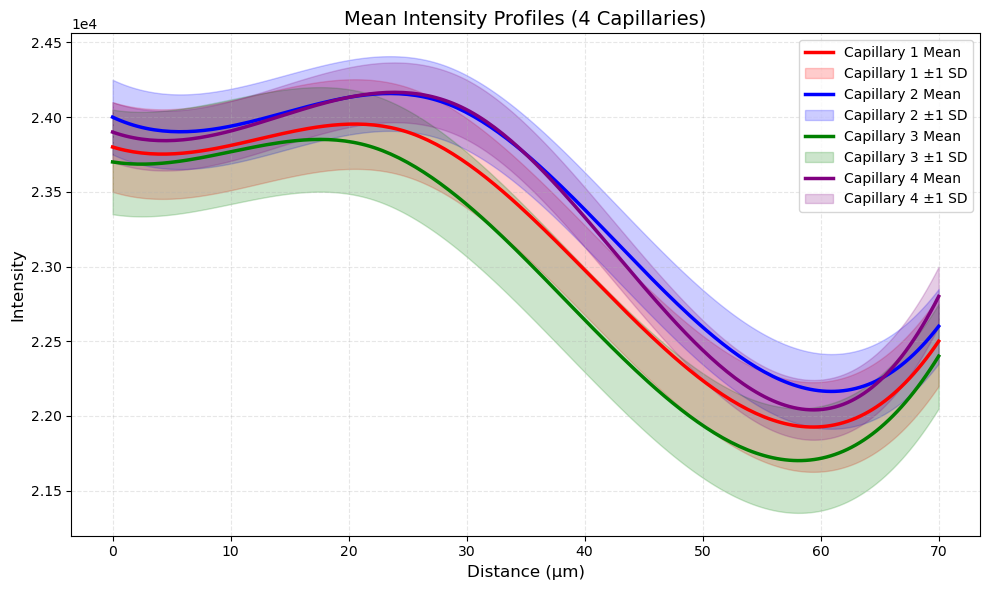

In [8]:
import numpy as np
import matplotlib.pyplot as plt
from scipy.interpolate import interp1d

# --- 1. Define Base Shape and X-axis ---
N_POINTS = 200
X_MIN, X_MAX = 0, 70  # Distance in μm
x = np.linspace(X_MIN, X_MAX, N_POINTS)

# --- 2. Define Parameters for 4 Capillaries ---
# Each profile is now defined by 5 key points to create the "rise-plateau-decay" shape
# (x_key_points), (y_key_points), std_dev
capillary_params = [
    # Profile 1
    ([0, 15, 25, 55, 70], [2.38e4, 2.39e4, 2.39e4, 2.20e4, 2.25e4], 300),
    # Profile 2 (starts higher, peaks higher)
    ([0, 18, 28, 58, 70], [2.40e4, 2.41e4, 2.41e4, 2.22e4, 2.26e4], 250),
    # Profile 3 (starts lower, decays more)
    ([0, 12, 22, 53, 70], [2.37e4, 2.38e4, 2.38e4, 2.18e4, 2.24e4], 350),
    # Profile 4 (longer plateau, ends higher)
    ([0, 16, 30, 56, 70], [2.39e4, 2.405e4, 2.405e4, 2.21e4, 2.28e4], 200),
]

colors = ['red', 'blue', 'green', 'purple']

# --- 3. Create the Plot ---
plt.figure(figsize=(10, 6))

for i, (x_key_points, y_key_points, std_dev) in enumerate(capillary_params):
    
    # a. Create a smooth cubic spline function using the 5 key points
    mean_func = interp1d(x_key_points, y_key_points, kind='cubic')
    
    # b. Calculate the smooth mean line
    mean_line = mean_func(x)
    
    # c. Get the color
    color = colors[i]
    
    # d. Plot the mean line
    plt.plot(x, mean_line, 
             color=color, 
             linewidth=2.5, 
             label=f'Capillary {i+1} Mean')
    
    # e. Plot the standard deviation
    plt.fill_between(x, mean_line - std_dev, mean_line + std_dev, 
                     color=color, 
                     alpha=0.2, 
                     label=f'Capillary {i+1} ±1 SD')

# --- 4. Style the Plot ---
plt.title("Mean Intensity Profiles (4 Capillaries)", fontsize=14)
plt.xlabel("Distance (μm)", fontsize=12)
plt.ylabel("Intensity", fontsize=12)
plt.legend()
plt.grid(True, linestyle='--', alpha=0.3)
plt.gca().ticklabel_format(axis='y', style='sci', scilimits=(0,0)) # Scientific notation
plt.tight_layout()
plt.show()